In [1]:
import geopandas as gpd
import pandas as pd
import numpy as np  
import networkx as nx
import matplotlib.pyplot as plt
import osmnx as ox
import matplotlib.cm as cm
import matplotlib.colors as colors
from shapely.ops import unary_union
from matplotlib.patches import FancyArrowPatch, FancyArrow
from matplotlib.legend_handler import HandlerPatch
from matplotlib.lines import Line2D
import csv

def prune_degree_one_nodes(G):
    G = G.copy()  # avoid modifying original graph
    changed = True

    while changed:
        # Find nodes with in-degree = 1 or out-degree = 1
        to_remove = [n for n in G.nodes if G.out_degree(n) == 0 and G.in_degree(n) < 2]

        if not to_remove:
            changed = False
        else:
            G.remove_nodes_from(to_remove)

    return G

def write_graph_to_csv(G, filename = 'graph.csv', weights = ['length']):
    # Open a CSV file in write mode
    with open('/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/'+filename, 
              'w', newline='') as csvfile:
        # Create a CSV writer object
        csvwriter = csv.writer(csvfile)
    
        # Write the header row (optional)
        csvwriter.writerow(['vertex1', 'vertex2']+weights)
    
        is_multi = G.is_multigraph()

        if is_multi:
            for u, v, data in G.edges(keys=False, data=True):
                w = data.get(weights[0], None)
                b = data.get(weights[1], None)
                csvwriter.writerow([u, v, w, b])
        else:
            for u, v, data in G.edges(data=True):
                w = data.get(weights[0], None)
                b = data.get(weights[1], None)
                csvwriter.writerow([u, v, w, b])

            
    print('Graph has been written to '+filename)

def write_positions_to_file(pos: dict, path:str):
    with open('/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/KSP/graphs_qspbwss/'+path, 'w') as csvfile:
        # Create a CSV writer object
        csvwriter = csv.writer(csvfile)
    
        # Write the header row (optional)
        csvwriter.writerow(['vertex1', 'x', 'y'])
    
        # Write edges and their weights to the CSV file
        for i, xy in pos.items():
            csvwriter.writerow([i, xy[0], xy[1]])

3911


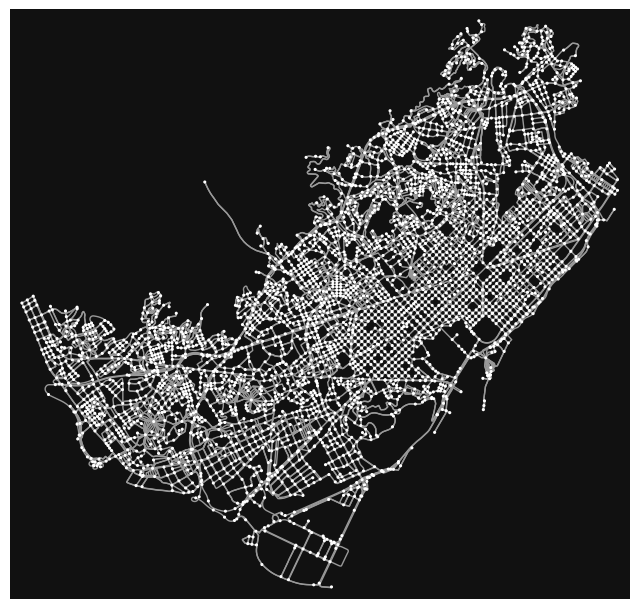

[3911]
284.1 3156.3628439750355 23.702398180690512 226.8205402257013
All travel times are finite. Writing to file...
Graph has been written to ../graphs_qspbwss/osm_cities/bcn_amb_graph.csv
3910 3911 9674


In [3]:
# Load surrounding municipalities and reproject to match city_gdf
gdf_bcn = ox.geocode_to_gdf("Barcelona, Spain")
gdf_espl = ox.geocode_to_gdf("Esplugues de Llobregat, Spain")
gdf_staco = ox.geocode_to_gdf("Santa Coloma de Gramenet, Spain")
gdf_stadr = ox.geocode_to_gdf("Sant Adrià de Besòs, Spain")
gdf_corn = ox.geocode_to_gdf("Cornellà de Llobregat, Spain")
gdf_stjn = ox.geocode_to_gdf("Sant Joan Despí, Spain")
gdf_stjst = ox.geocode_to_gdf("Sant Just Desvern, Spain")
gdf_stfl = ox.geocode_to_gdf("Sant Feliu de Llobregat, Spain")
gdf_hosp = gpd.read_file("/Users/robertbenassai/Documents/UOC/k_shortest_path_betweenness/DivisioLH_BAR/DivisioLH_BAR.shp").to_crs(gdf_bcn.crs)

# Combine all geometries into one GeoDataFrame
amb_gpd = gpd.GeoDataFrame(
    pd.concat([gdf_bcn, gdf_espl, gdf_staco, gdf_stadr, gdf_hosp,
               gdf_corn, gdf_stjn, gdf_stjst, gdf_stfl], ignore_index=True),
    geometry="geometry",
    crs=gdf_bcn.crs
)

G = ox.graph_from_polygon(unary_union(amb_gpd.geometry), network_type="drive")
# define fundamental road types
fundamental = [
    "motorway", "motorway_link",
    "trunk", "trunk_link",
    "primary", "primary_link",
    "secondary", "secondary_link",
    "tertiary", "residential", "unclassified"
]

# keep only fundamental road types
edges = ox.graph_to_gdfs(G, nodes=False)
fundamental_mask = edges["highway"].isin(fundamental)
fundamental_edges = edges[~fundamental_mask].index
G.remove_edges_from(fundamental_edges)

#prune graph to only keep the largest strongly connected component
G = ox.utils_graph.get_largest_component(G, strongly=True)
G.remove_edges_from(nx.selfloop_edges(G))
G = ox.project_graph(G)                      # ensures metric units
G = ox.consolidate_intersections(G, tolerance=35, rebuild_graph=True)
G = prune_degree_one_nodes(G) 


edges = ox.graph_to_gdfs(G, nodes=False)

# remove bus lanes and busways
bus_mask = (
    edges["access"].fillna("").str.contains("bus|no", case=False)
    | edges["highway"].fillna("").str.contains("busway|bus_guideway", case=False)
    # | edges["bus"].fillna("").str.contains("yes", case=False)
    # | edges["lanes:bus"].fillna("").str.contains("yes", case=False)
    # | edges["busway"].fillna("").str.contains("yes|opposite", case=False)
    # | edges["bus:lanes"].fillna("").str.contains("designated|yes", case=False)
)

bus_edges = edges[bus_mask].index
G.remove_edges_from(bus_edges)

# remove isolated nodes
G.remove_nodes_from(list(nx.isolates(G)))

# get the travel times
#G = ox.distance.add_edge_lengths(G)

#change lengths to kms
edge_lens = nx.get_edge_attributes(G, 'length')
# for u, v, k in G.edges(keys=True):

#     # use the edge_lens entry keyed by (u, v, k)
#     G[u][v][k]['length'] = edge_lens[(u, v, k)] / 1000.0  # convert to kilometers
   
G = ox.add_edge_speeds(G)
G = ox.add_edge_travel_times(G)
# remove links from the cathegory 
# Get the boundary polygon of Esplugues de Llobregat

# The polygon geometry is in gdf.geometry[0]
node_ids = {node: i for i, node in enumerate(G.nodes)}
nx.set_node_attributes(G, node_ids, name='node_id')

nx.relabel_nodes(G, node_ids, copy=False)
print(len(G.nodes))

# Build a node position dict from the nodes GeoDataFrame (request nodes=True)
nodes_gdf = ox.graph_to_gdfs(G, nodes=True, edges=False)
edges_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True)
pos = nodes_gdf.geometry.representative_point().apply(lambda p: p.coords[0]).to_dict()

# nx.draw_networkx(G, pos=pos, node_size=0, edge_color='black', with_labels=False)
ox.plot_graph(G, node_size=5)
# check connected components
print([len(c) for c in sorted(nx.connected_components(nx.to_undirected(G)), key=len, reverse=True)])

# Save graph to file
# check if all travel times are finite
travel_times = [data['travel_time'] for u, v, data in G.edges(data=True)]
lengths = [data['length'] for u, v, data in G.edges(data=True)]


print(np.max(travel_times), np.max(lengths), np.mean(travel_times), np.mean(lengths))
if all(np.isfinite(travel_times)):
    print("All travel times are finite. Writing to file...")
    write_graph_to_csv(G, filename='../graphs_qspbwss/osm_cities/bcn_amb_graph.csv', weights=['travel_time', 'maxspeed'])
    write_positions_to_file(pos, path='../graphs_qspbwss/osm_cities/bcn_amb_node_pos.csv')
else:
    print("Some travel times are not finite. Aborted writing to file.")

print(np.max(G.nodes), len(G.nodes), len(G.edges))

In [4]:
print(G.get_edge_data(0, 1))

{0: {'osmid': [1433594636, 4079500, 543357596, 902517725, 423227070], 'oneway': False, 'lanes': ['4', '3'], 'name': 'Passeig de Joan de Borbó', 'highway': 'residential', 'maxspeed': '30', 'reversed': True, 'length': 677.4118575085063, 'geometry': <LINESTRING (432075.356 4580143.474, 432071.186 4580160.408, 432066.515 4580...>, 'u_original': 21638845, 'v_original': 13175411896, 'speed_kph': 30.0, 'travel_time': 81.3}}
